## Compare ZTF BTS Predictions

In this notebook we will find objects that overlap with both the ZTF Bright Transient Survey (BTS) and our samples, use the ZTF g- and r-band photometry to predict photometry in the UV filters, and check those predictions against the real values to verify how well our models can extrapolate SEDs into the UV using rest-frame optical data.

In [34]:
import pandas as pd
from caat import SNCollection, SNModel

SNTYPE = "SESNe"
SNSUBTYPE = "SNIb"

sncollection = SNCollection(sntype=SNTYPE, snsubtype=SNSUBTYPE)
ztf_bts_sample = pd.read_csv("ztf_bts_objects.csv", header=0)

obj_names_to_compare = []
for obj in sncollection.sne:
    if obj.name in ztf_bts_sample["IAUID"].values:
        obj_names_to_compare.append(obj.name)

INFO:caat.SNCollection:Loading SN Type: SESNe, Subtype: SNIb
INFO:caat.SNCollection:['SN2016adj' 'SN2004dk' 'SN2019tsf' 'SN2010O' 'SN2007C' 'SN2021uhk'
 'SN2019yvr' 'SN2023dtc' 'SN2019dge' 'SN2019dgz' 'SN2012au' 'SN2009jf'
 'SN2019oys' 'SN2018beh' 'SN2007uy' 'SN2022nyo' 'SN2021niq' 'SN2011am'
 'SN2022hgk' 'SN2020hvp' 'SN2006dn' 'SN2017bgu' 'SN2016bau' 'SN2010cn'
 'SN2003gk' 'SN2022ryd' 'SN2018alc' 'SN2001ej' 'SN2004ao' 'SN2004gq'
 'SN2004gv' 'SN2005bf' 'SN2005hg' 'SN2006F' 'SN2006cb' 'SN2006el'
 'SN2006ep' 'SN2006fo' 'SN2006gi' 'SN2006lc' 'SN2006ld' 'SN2006lv'
 'SN2007ag' 'SN2007ke' 'SN2007kj' 'SN2008D' 'SN2009er' 'SN2009iz']


SN2021uhk
########################



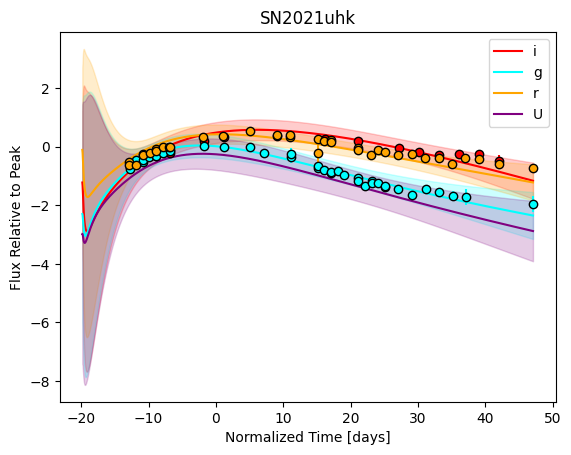

SN2019dge
########################



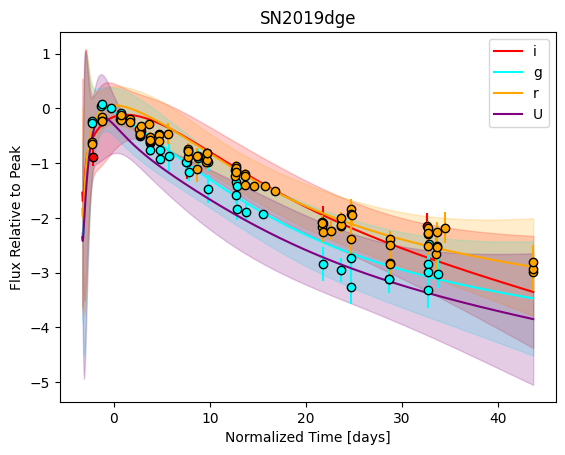

SN2019dgz
########################



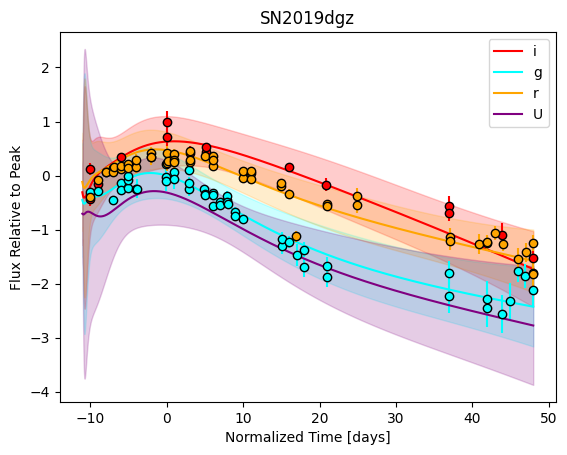

SN2021niq
########################



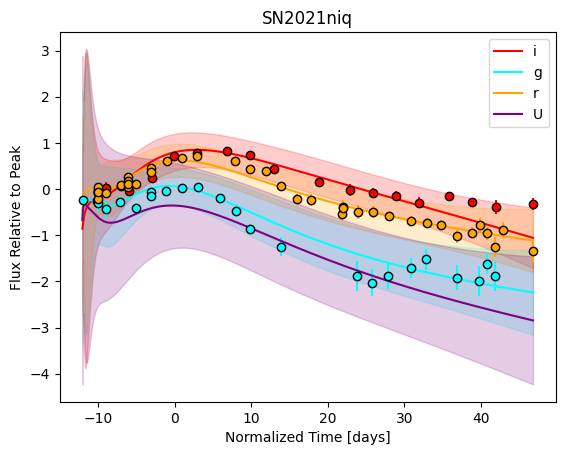

SN2022hgk
########################



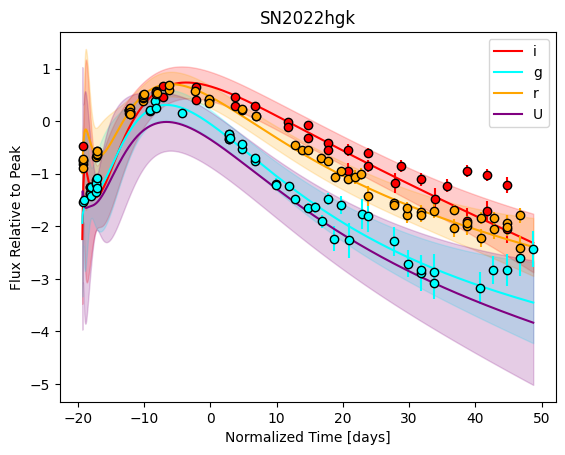

SN2020hvp
########################



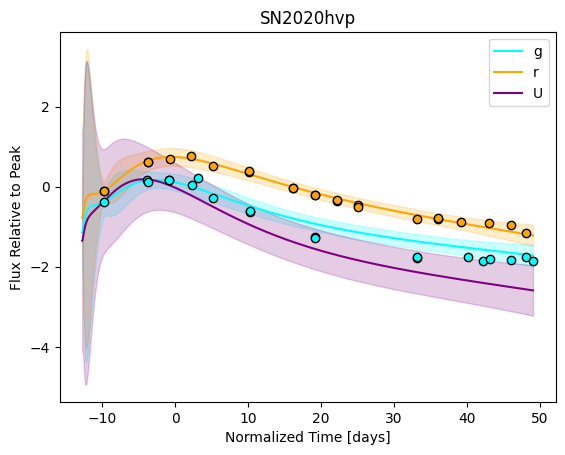

SN2021uhk
########################



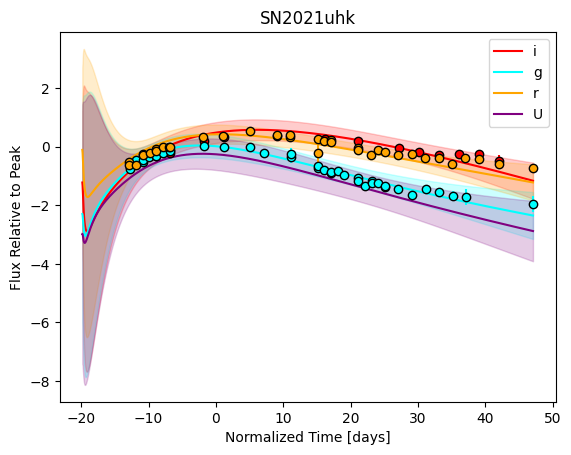

SN2019dge
########################



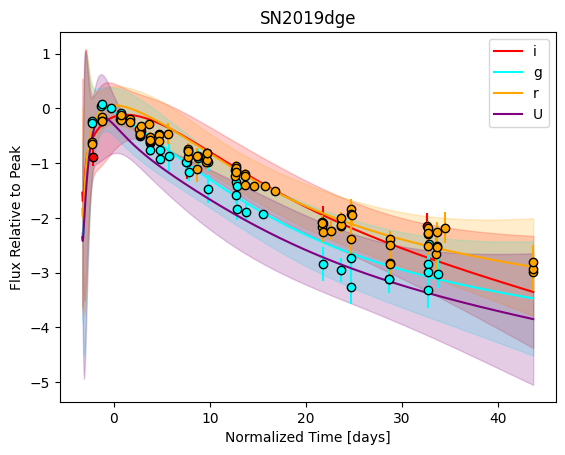

SN2019dgz
########################



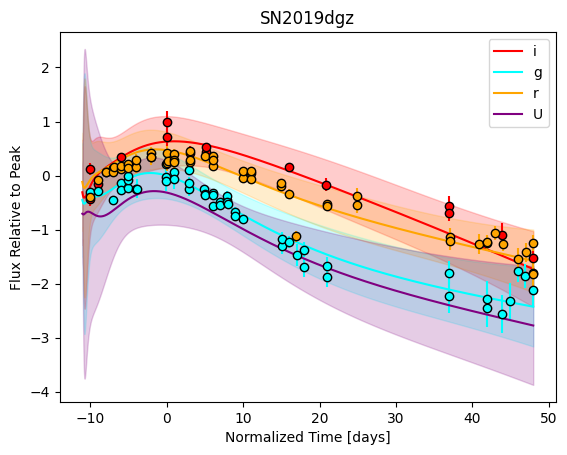

SN2021niq
########################



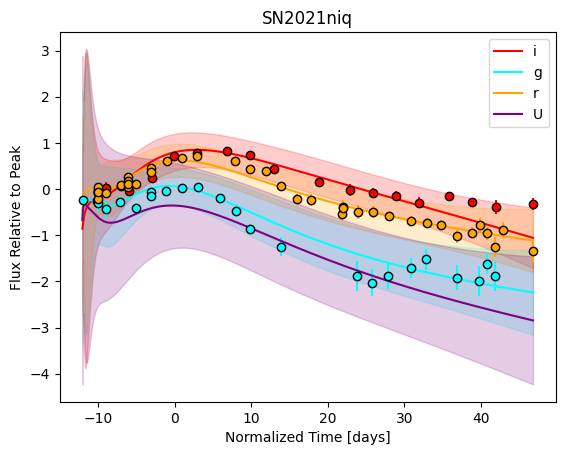

SN2022hgk
########################



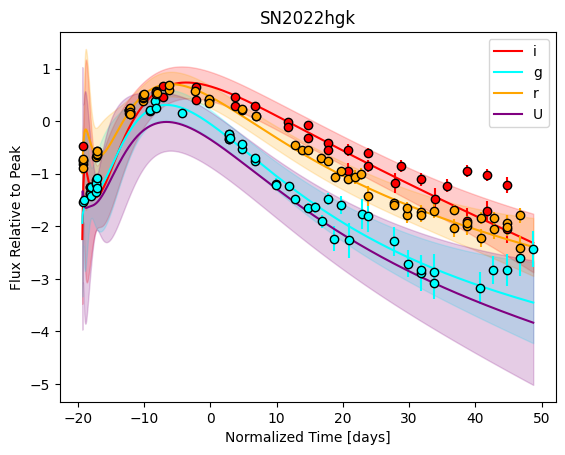

SN2020hvp
########################



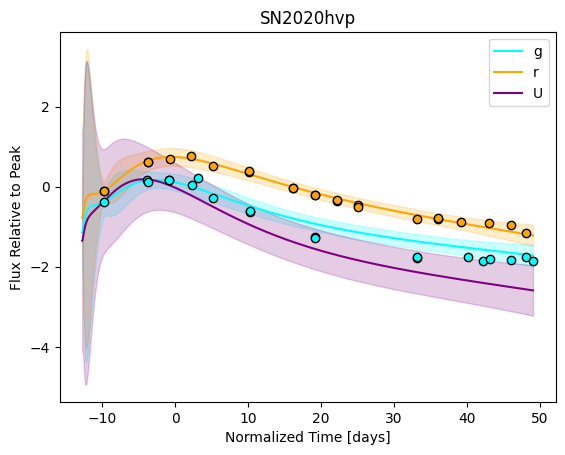

SN2021uhk
########################



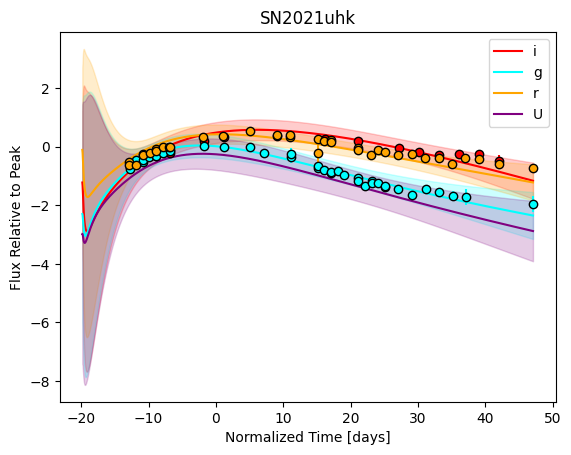

SN2019dge
########################



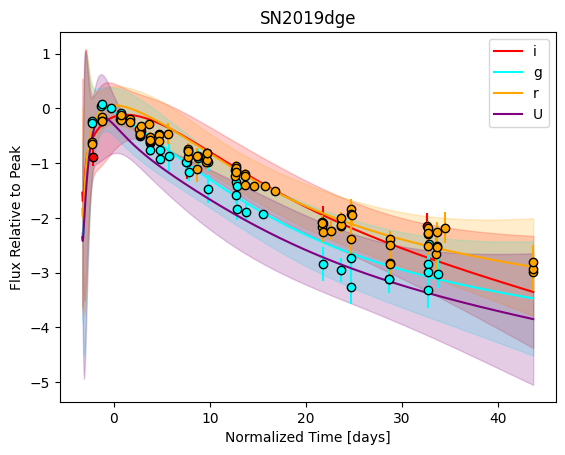

SN2019dgz
########################



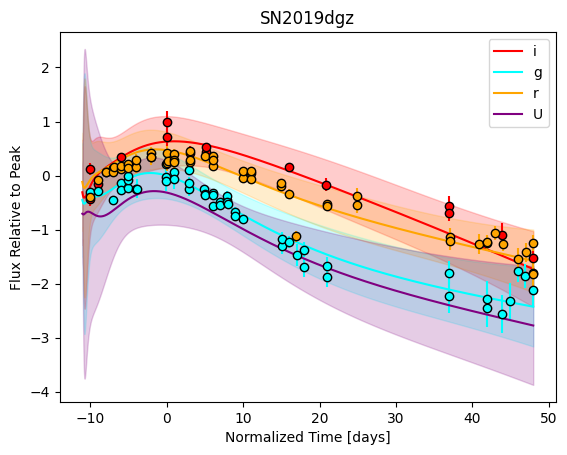

SN2021niq
########################



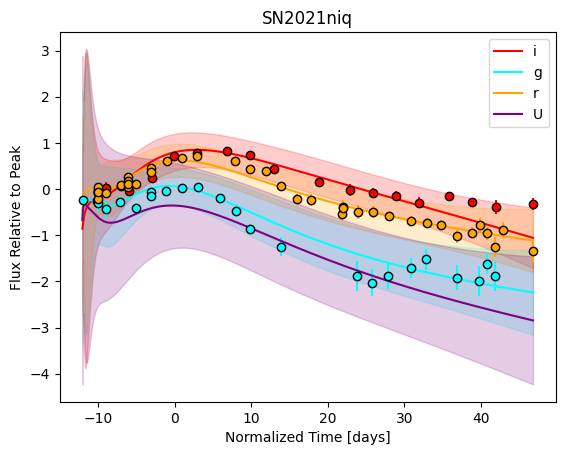

SN2022hgk
########################



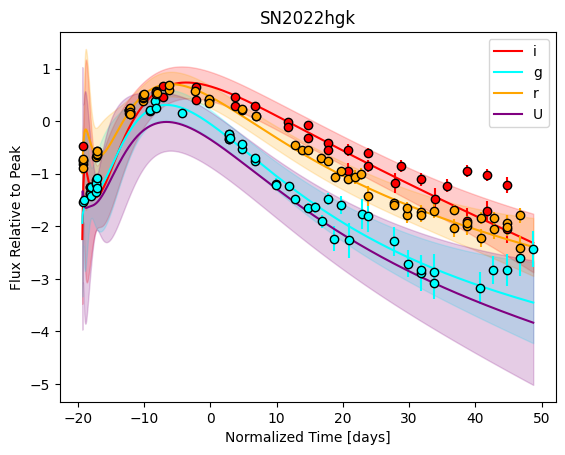

SN2020hvp
########################



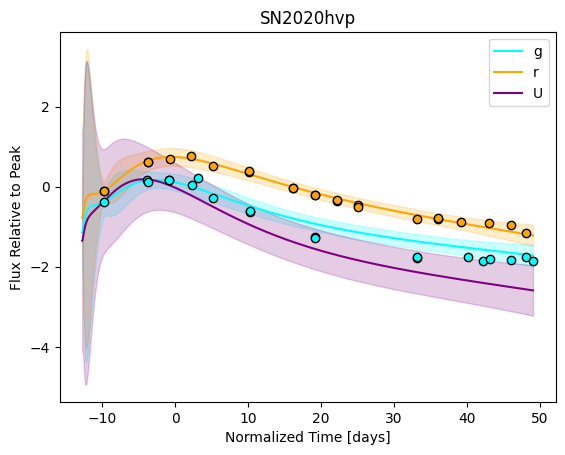

In [35]:
import numpy as np
import matplotlib.pyplot as plt

from caat.utils import WLE, convert_shifted_fluxes_to_shifted_mags

from util import load_datacube, predict_gopreaux


sne_to_fit = SNCollection(names=obj_names_to_compare)

diff_df = pd.DataFrame([], columns=["Name", "Filter", "Phase", "PredictedMag", "ObservedMag", "Residual"])

for filt_to_compare in ["UVM2", "UVW1", "U"]:
    for sn in sne_to_fit.sne:
        print(sn.name)
        print("########################\n")
        snmodel = SNModel(f"{SNTYPE}_{SNSUBTYPE}_GP_model.fits")

        try:
            snmodel.fit_photometry(
                sn_to_fit=sn,
                show=True,
                nsamples=1,
                filters_to_fit=["g", "r", "i"],
                keep_new_fit=True,
            )

        except ValueError as e:
            print("No photometry in these filters within the bounds of the GP fit")
            print(e)
            continue

        ### Get epochs of U-band photometry from SN phot/data cube
        cube = load_datacube(sn.name, sn.classification, sn.subtype, snmodel.min_phase, snmodel.max_phase)
        filtered_cube = cube[
            (cube["Filter"] == filt_to_compare)
            & (cube["Phase"] >= snmodel.min_phase)
            & (cube["Phase"] <= snmodel.max_phase)
        ]
            
        ### Predict photometry at those epochs and shift to apparent mags
        if len(filtered_cube):
            gopreaux_predictions = predict_gopreaux(snmodel, filtered_cube, plot=False)

            # snmodel.predict_lightcurve(
            #     phase_min=gopreaux_predictions["Phase"].min(),
            #     phase_max=gopreaux_predictions["Phase"].max(),
            #     wavelength=WLE[filt_to_compare],
            #     show=True
            # )

            gopreaux_predictions["GOPREAUX_mag"] = gopreaux_predictions["GOPREAUX_mag"].apply(
                convert_shifted_fluxes_to_shifted_mags,
                args=(sn, sn.zps[filt_to_compare])
            )

            phases = gopreaux_predictions["Phase"].values
            diffs = gopreaux_predictions["GOPREAUX_mag"].values + gopreaux_predictions["ShiftedMag"].values
            errs = np.sqrt(gopreaux_predictions["GOPREAUX_err"].values**2 + gopreaux_predictions["Magerr"].values**2)

            # fig, ax = plt.subplots()

            # ax.errorbar(phases, gopreaux_predictions["GOPREAUX_mag"].values, yerr=gopreaux_predictions["GOPREAUX_err"].values, fmt='o', color='blue', label="Predicted Mag")
            # ax.errorbar(phases, -1*gopreaux_predictions["ShiftedMag"].values, yerr=gopreaux_predictions["Magerr"].values, fmt='o', color='green', label="Observed Mag")
            
            # ax.errorbar(phases, diffs, yerr=errs, fmt='o', color='k', label="Residual")
            # ax.set_xlabel("Phase [days]")
            # ax.set_ylabel("Magnitude Relative to Peak")
            # ax.set_title(sn.name)
            # plt.legend()
            # plt.show()

            for phase, predicted_mag, observed_mag, diff in zip(phases, gopreaux_predictions["GOPREAUX_mag"].values, -1*gopreaux_predictions["ShiftedMag"].values, diffs):
                diff_df.loc[len(diff_df)] = [sn.name, filt_to_compare, phase, predicted_mag, observed_mag, diff]
            

In [36]:
def save_results(df: pd.DataFrame):
    """
    Save the results to a csv file for later.

    Args:
        df (pd.DataFrame): DataFrame containing the results
            (name, phase, filter, predicted mag, observed mag, and residual).
    """
    df.to_csv(f"results/ztf_bts/{SNTYPE}_{SNSUBTYPE}.csv")

# save_results(diff_df)

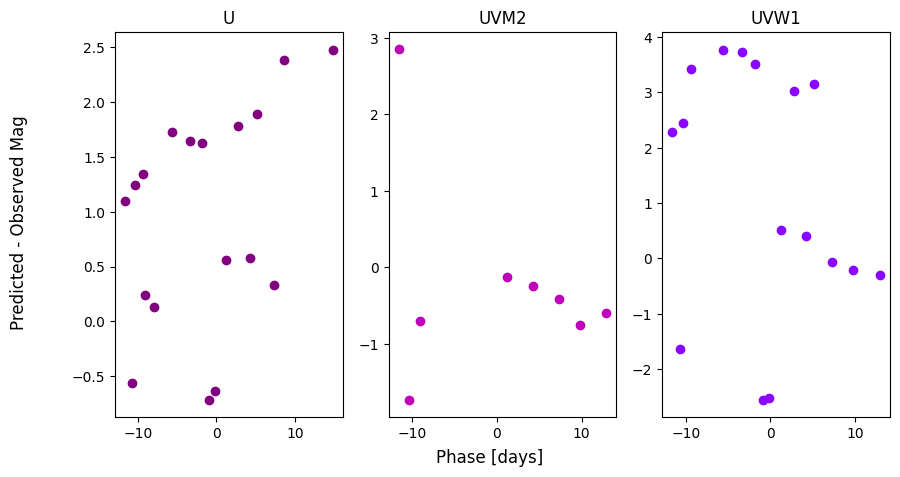

In [38]:
from caat.utils import colors as FILT_COLORS

fig, ax = plt.subplots(1, len(diff_df["Filter"].unique()), figsize=(10,5))
i = 0
for filt, filt_grp in diff_df.groupby("Filter"):
    ax[i].scatter(filt_grp["Phase"], filt_grp["Residual"], color=FILT_COLORS[filt], label=filt)
    ax[i].set_title(filt)
    
    i += 1

fig.supxlabel("Phase [days]")
fig.supylabel("Predicted - Observed Mag")
plt.show()

In [67]:
def plot_diff_histograms(
    results: pd.DataFrame,
    bins: int = 15,
    min_phase: float | None = None,
    max_phase: float | None = None,
) -> None:
    """
    Plot per-filter histograms of residuals.

    Args:
        results: DataFrame output with residuals per filter
        bins: int, number of bins to plot
        min_phase: float, minimum phase to consider
        max_phase: float, maximum phase to consider
    """
    diff_df = results.copy()

    filters = sorted(diff_df["Filter"].unique())
    n_filts = len(filters)

    fig, axes = plt.subplots(1, n_filts, figsize=(3 * n_filts, 6), sharey="row")
    if n_filts == 1:
        axes = axes[:, np.newaxis]

    if min_phase is not None:
        diff_df = diff_df[diff_df["Phase"] > min_phase]

    if max_phase is not None:
        diff_df = diff_df[diff_df["Phase"] < max_phase]

    all_vals = diff_df["Residual"].dropna()
    
    shared_range = (all_vals.min(), all_vals.max())

    for ax, filt in zip(axes, filters):
        vals = diff_df.loc[diff_df["Filter"] == filt, "Residual"].dropna()
        ax.hist(vals, bins=bins, range=shared_range, color="steelblue",
                edgecolor="white", linewidth=0.5)
        ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
        ax.axvline(vals.median(), color="red", linestyle="-", linewidth=1.2,
                    label=f"median = {vals.median():.3f}")
        ax.legend(fontsize=7, loc="upper right")
        ax.set_title(filt)
        ax.set_xlabel("Residual [mag]" if ax == axes[0] else "")
        if ax == axes[0]:
            ax.set_ylabel("Count")

    fig.suptitle(
        "Predicted - Observed Mag\n"
        "(negative = GOPREAUX fainter, positive = GOPREAUX brighter)",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

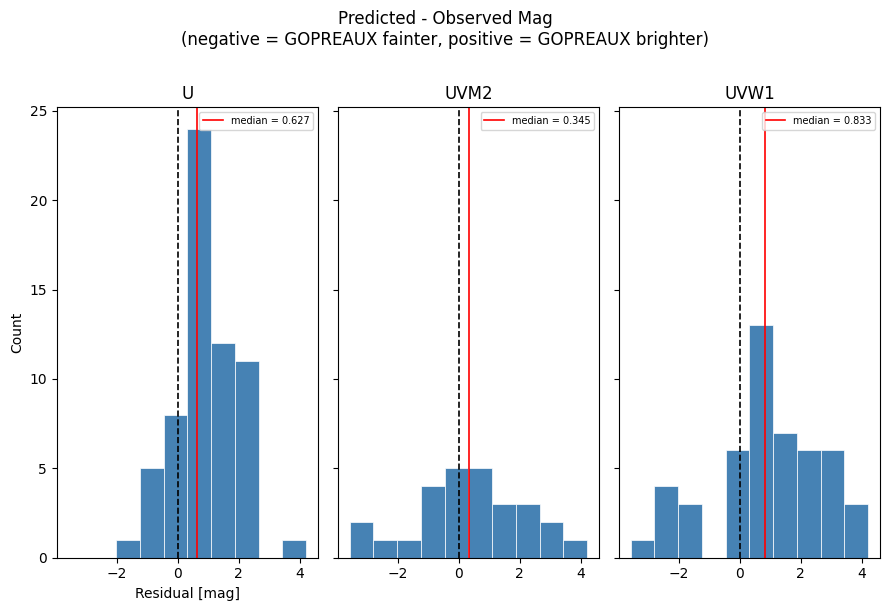

In [68]:
iib_diffs = pd.read_csv("results/ztf_bts/SESNe_SNIIb.csv")
ib_diffs = pd.read_csv("results/ztf_bts/SESNe_SNIb.csv")
ic_diffs = pd.read_csv("results/ztf_bts/SESNe_SNIc.csv")

sesne_diffs = pd.concat([iib_diffs, ib_diffs, ic_diffs], ignore_index=True)
plot_diff_histograms(sesne_diffs, bins=10)